### Quantum MAXCUT

The quantum maxcut problem is defined in terms of the Heisenberg Hamiltonian. 

$$H = - \sum_{(i,j) \in E} \frac{I - \sigma_x^i \sigma_x^j - \sigma_y^i \sigma_y^j - \sigma_z^i \sigma_z^j}{4}$$

Where $G = (V,E)$ is given as input. The Hamiltonian can be block diagonalized (since it's hermitian) and each block corresponds to the laplacian of the token graph $F_k$.

In [1]:
using QuantumOptics
using Arpack
using Plots
using LinearAlgebra
using Test
using Combinatorics
import Base: isless

A **token graph** $F_k$ is defined by a graph $G = (V,E)$ and an integer $0 \leq k \leq |V|$. 

We first define the structure of the graph $G$

* *Node*: Represents a node of $G$. Defined as a Int.
* *Edge*: Relation between two Nodes.
* *Graph*: Made up of a numbre $n$ (number of nodes), and a list of nodes and edges.

Moreover we define an equality measure for edges and an order for nodes.

In [2]:
# Graph structure definition
struct Node
    el::Int
end

struct Edge
    first::Node
    second::Node
end

struct Graph
    n::Int
    nodes::Vector{Node}
    edges::Vector{Edge}
end

isless(x::Node, y::Node) = isless(x.el, y.el)

Base.:(==)(a::Edge, b::Edge) = (a.first == b.first && a.second == b.second) ||
                               (a.first == b.second && a.second == b.first) 

Now we model the **behaviour** of a graph, by introducing the following functions:

* *add_Node*: Adds a node to the graph
* *init_Nodes*: Generates nodes from $1$ to $n$ and adds them to the graph
* *node_exist*: Returns *True* if a node is inside the Graph, *False* otherwise
* *edge_exist*: Returns *True* if an edge is inside the Graph, *False* otherwise
* *add_Edge*: Adds an edge to the graph

In [60]:
# Graph functions
function add_Node(G::Graph,i::Node)
    for j in 1:G.n
        if i == j
            throw(ArgumentError("Node already exists"))
        end
    end
    push!(G.nodes,i)
    sort!(G.nodes)
end

function init_Nodes(myGraph::Graph)
    for i in 1:myGraph.n
        add_Node(myGraph,Node(i))
    end
end

function node_exist(myGraph::Graph,i::Node)
    for j in myGraph.nodes
        if j == i
            return true
        end
    end
    return false
end

function edge_exist(G::Graph,i::Node,j::Node) # Maybe if you ask for the edge directly it becomes agnostic to the implementation. Wouldn't be bad.
    if !node_exist(G,i) || !node_exist(G,j)
        throw(ArgumentError("Node doesn't exist"))
    end
    
    for e in G.edges
        if e == Edge(i,j) || e == Edge(j,i)
            return true
        end
    end
    
    return false
end

function add_Edge(G::Graph,i::Node,j::Node)
    if i == j
        throw(ArgumentError("Loops aren't allowed"))
    end

    if edge_exist(G,i,j) 
        throw(ArgumentError("Edge already exists"))
    end

    push!(G.edges,Edge(i,j))
end;

Our goal is to obtain the **laplacian** of the token graph $F_{\lfloor \frac{n}{2}\rfloor}$, defined as
$$L = A - D$$
where $A$ is the adjacency matrix and $D$ the degree matrix.
In particular, we implement the following functions:

* tuple_to_mask: Takes a tuple (e.g. [1,2,4]) and converts it a number. In binary, the elements of the tuple are the positions of $1$s (e.g. 2^1 + 2^2 + 2^4).
* token_nodes: Generates all nodes of the token graph as strings.
* laplacian: Generates the lalpacian matrix L of the token graph.

In [59]:
function tuple_to_mask(t)
    m = 0
    for i in t
        m |= (1 << (i - 1))
    end
    return m
end

function token_nodes(G::Graph)
    n = G.n
    k = Int(floor(n/2))
    c = combinations(1:n,k)
    v = []
    
    for i in c
        s = lpad(string(tuple_to_mask(i),base=2), n, '0')
        push!(v,s)
    end
    
    return v
end

function laplacian(G::Graph)
    n = G.n
    k = Int(floor(n/2))
    L = zeros(binomial(n,k),binomial(n,k))
    edges = G.edges

    v = token_nodes(G)
    for s in v
        i = findfirst(==(s), v)
        
        for e in edges
            a = e.first.el
            b = e.second.el
            if s[a] != s[b]
                L[i,i] += 1
                temp = collect(s)
                temp[n -  a + 1],temp[n - b + 1] = temp[n - b + 1],temp[n - a + 1]
                j = findfirst(==(String(temp)),v)
                L[i,j] = 1
            end
        end
    end
    return L
end;

We would like to be able to generate **random** graphs to test if our initial Hamiltonian is robust enough.

* generate_graph: Returns a graph of $n$ nodes with randomly generated edges.

In [58]:
function generate_graph(n)
    G = Graph(n, Node[], Edge[]) 
    init_Nodes(G)
    e = rand(1:n*(n-1)/2)
    for l = 1:e
        while true
            i = rand(1:n)
            j = 0
            while true
                j = rand(1:n)
                if i != j 
                    break
                end
            end

            if i > j
                i,j = j,i
            end
            
            if !edge_exist(G,Node(i),Node(j))
               add_Edge(G,Node(i),Node(j))
                break
            end
        end
    end
    return G
end;

### Adiabatic

In [57]:
b = SpinBasis(1/2)
z = sigmaz(b)
y = sigmay(b)
x = sigmax(b)
i = identityoperator(b);

In [56]:
function sim(T,dt,term_0,term_1,psi)
    time = 0:T
    
    if !isnothing(dt)
        time = 0:dt:T
    end
    
    function H(t,psi)
        s = t/T
        return (1-s)*term_0 + s * term_1
    end
    tout, res = timeevolution.schroedinger_dynamic(time, psi, H)
    
    return res
end

function plot_spectrum(term_0,term_1,n)
    if !ishermitian(dense(term_0).data)
        throw(DomainError(dense(term_0).data,"Hamiltonian must be hermitian"))
    end
    s_vals = 0:0.01:1.0
    num_states = 2^n
    energies = zeros(length(s_vals), num_states)

    for (i, s) in enumerate(s_vals)
        Hs = (1 - s) * term_0 + s * term_1
        energies[i, :] = eigvals(Hermitian(Array(dense(Hs).data)))
    end
    display(plot(s_vals, energies, 
         lw=2, 
         title="Energy Spectrum",
         xlabel="s", 
         ylabel="Energy",
         legend=:false))
end

function plot_exp_value(term_0,term_1,psi,dt,T)
    s_vals = 0:dt:T
    energies = zeros(length(s_vals))

    for (i, s) in enumerate(s_vals)
        s /= T
        Hs = (1 - s) * term_0 + s * term_1
        energies[i] = (psi[i]' * Hs * psi[i]).re
    end

    display(plot(s_vals, energies, 
         lw=2, 
         title="Exp value",
         xlabel="s", 
         ylabel="Exp value",
         legend=:false))
end;

Following the work of [Wong et al](https://arxiv.org/abs/2602.03605), we use the Hamiltonian
$$H_s = - \sum_{(i,j) \in E} \ket{\psi_s}\bra{\psi_s}$$
where $\ket{\psi_s} = \ket{00} + s\ket{11}$. We use as starting hamiltonian $H_0$ ($H_s$ with $s=0$). Note that the edges are of the token graph associated with the initial graph $G$. It's possible that using this as starting hamiltonian the adiabatic evolution will yield a good result on a generic instance. Here is the experiment that follows:

* Given a graph G we obtain its token equivalent. We then generate the initial hamiltonian $H_0$ and its ground state $\ket{\psi_s}$. Finally, through adiabatic evolution we estimate the ground state of QMC.

We begin with generating the final hamiltonian, e.g. the hamiltonian of which we want to find the ground state.
First, given a number $n$, let's generate a random graph. Then, we embed the laplacian of its token graph into a bigger space (to match a power of two).

In [61]:
n = 4
k = Int(floor(n/2))

G = generate_graph(n)
L = laplacian(G)

m = nextpow(2,binomial(n,k))
s = Int(log2(m))

H_f = zeros(m,m)
H_f[1:binomial(n,k),1:binomial(n,k)] = -L

H_f = Operator(b^s,b^s,H_f);

Next we need to generate the initial hamiltonian. We use the lazy tensor function provided by quantumOptics package, and then shrink it down to the same size as the final hamiltonian, by keeping only the entries that, in binary, have hamming weight $k$.

In [54]:
B = b^n

term_0 = - LazySum([
    0.25 * (one(B) +  LazyTensor(B, [e.first.el, e.second.el], (z, z)) +  LazyTensor(B, [e.first.el], (z,)) + LazyTensor(B, [e.second.el], (z,)))  
    for e in G.edges
]...)

A = zeros(m,2^n)

j = 1
for e in token_nodes(G)
    i = parse(Int,e,base=2)
    A[j,:] = dense(term_0).data[i,:]
    j += 1
end

B = zeros(m,m)
j = 1
for e in token_nodes(G)
    i = parse(Int,e,base=2)
    B[:,j] = A[:,i]
    j += 1
end

H_0 = Operator(b^s,b^s,complex(B));

All there is left to do is to generate the ground state of the Hamiltonian.
We define the funciton

* ground_state: returns the ground state (in ket form) of a matrix.

In [63]:
function ground_state(m,H,B)
    v = zeros(m)

    d = 0
    for j = 1:m
        if H[j,j] < d
            v = H[:,j]
            d = H[j,j]
        end
    end
    normalize!(v)
    v = complex(v)
    return Ket(B,v)
end

ground = ground_state(m,B,b^s);

We can finally run the simulation and observe the results

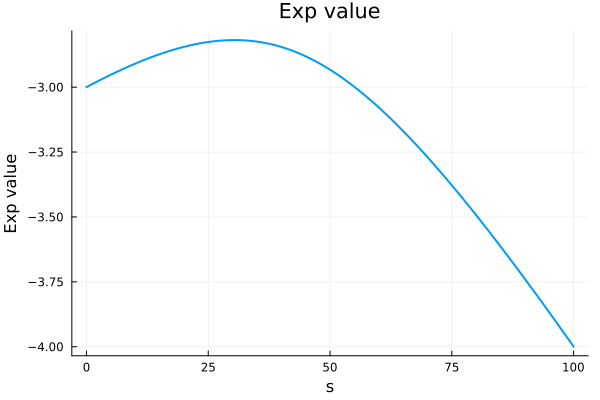

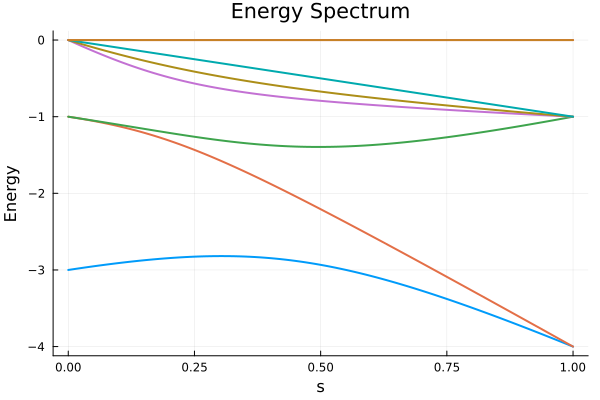

In [64]:
T = 100
dt = 0.1

res = sim(T,dt,H_0,H_f,ground)

plot_exp_value(H_0,H_f,res,dt,T)

plot_spectrum(H_0,H_f,s)